<a href="https://colab.research.google.com/github/Rishsing73/rishsing73.github.io/blob/master/Segmentation_nasal_Cavity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing important libraries
### Here we install segmentation models , tensorflow and keras. all three are very crucial  to the model, especially to the pretraining model we want to fine tune.



In [ ]:
!pip install segmentation-models
!pip install  tensorflow==2.1.0
!pip install keras==2.3.1
import tensorflow as tf
import segmentation_models as sm
import glob
import cv2
import os
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow
import albumentations as A

     |████████████████████████████████| 51kB 4.2MB/s 
     |████████████████████████████████| 421.8MB 23kB/s 
     |████████████████████████████████| 450kB 37.0MB/s 
     |████████████████████████████████| 3.9MB 43.9MB/s 
  Created wheel for gast: filename=gast-0.2.2-cp36-none-any.whl size=7540 sha256=247a6a93621d9e3d8cadd2460a80fd26b5dc7da40d1387c1ae6bc3cc8028e451
  Stored in directory: /root/.cache/pip/wheels/5c/2e/7e/a1d4d4fcebe6c381f378ce7743a3ced3699feb89bcfbdadadd
Successfully built gast
ERROR: tensorflow-probability 0.12.1 has requirement gast>=0.3.2, but you'll have gast 0.2.2 which is incompatible.
  Found existing installation: tensorflow-estimator 2.4.0
    Uninstalling tensorflow-estimator-2.4.0:
      Successfully uninstalled tensorflow-estimator-2.4.0
  Found existing installation: tensorboard 2.4.0
    Uninstalling tensorboard-2.4.0:
      Successfully uninstalled tensorboard-2.4.0
  Found existing installation: gast 0.3.3
    Uninstalling gast-0.3.3:
      Successfully 

Using TensorFlow backend.


Segmentation Models: using `keras` framework.


## Mounting google Drive
#### we have all our data inside google drive. to access the data we are mounting the drive with the help of tools provided by colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
transform = A.Compose([
    A.HorizontalFlip(p=1),])



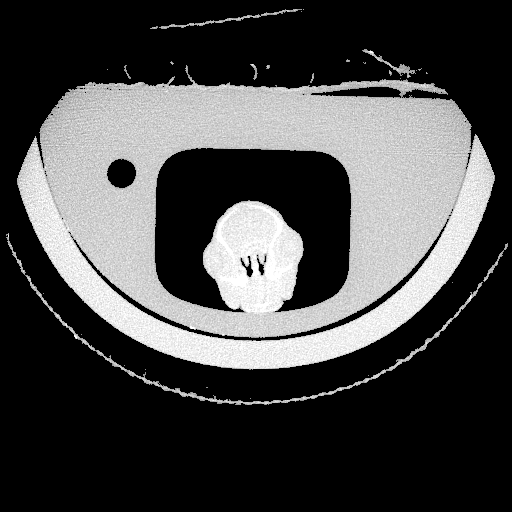

(272, 512, 512, 3)

In [ ]:
l = os.listdir('drive/MyDrive/train_png')
dir_files = l
d = np.sort(dir_files)
train_images = []
i = 0
for directory_path in glob.glob("/content/drive/My Drive/train_png"):
  for i in range(len(d)):
    for img_path in glob.glob(os.path.join(directory_path, d[i])):
      img = cv2.imread(img_path)
      color_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      train_images.append(color_img)
      transformed = transform(image=color_img)
      transformed_image = transformed["image"]
      train_images.append(transformed_image)   
train_images = np.array(train_images)

cv2_imshow(train_images[27])
np.shape(train_images)


In [ ]:
train_masks = [] 
l = os.listdir('drive/MyDrive/mask_Data')
dir_files = l
d = np.sort(dir_files)
i = 0
mask1 = cv2.imread("/content/drive/My Drive/mask_Data/mask01")
for directory_path in glob.glob("/content/drive/My Drive/mask_Data"):
  for i in range(len(d)):
    for img_path in glob.glob(os.path.join(directory_path, d[i])):
        mask = cv2.imread(img_path) 
        k = mask[:,:,0] 
        train_masks.append(k)
        transformed = transform(image=k)
        transformed_image = transformed["image"]
        train_masks.append(transformed_image)      
train_masks = np.array(train_masks)
len(train_masks)
# cv2_imshow(train_masks[0])


272

In [ ]:
# transform = A.Compose([
#     A.HorizontalFlip(p=0.8),
#     A.RandomBrightnessContrast(p=0.2),
# ])

# transformed = transform(image=image, masks=masks)
# transformed_image = transformed['image'] 
# transformed_masks = transformed['masks']

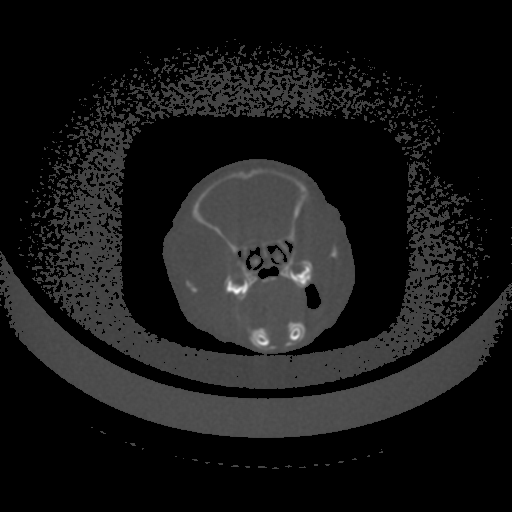

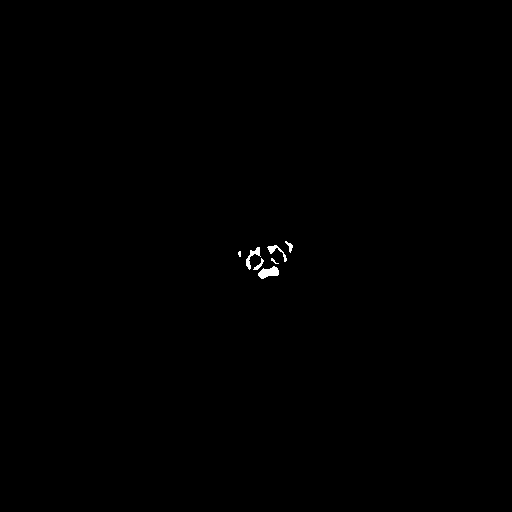

In [ ]:
BACKBONE = 'resnet34'
preprocess_input = sm.get_preprocessing(BACKBONE)
X = train_images
Y = train_masks
Y = np.expand_dims(Y, axis=3)
cv2_imshow(X[6])
cv2_imshow(Y[6])
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.15, random_state=42)

In [ ]:
x_train = preprocess_input(x_train)
x_val = preprocess_input(x_val)
metrics = [
    sm.metrics.IOUScore(threshold=0.5),
]
model = sm.Unet(BACKBONE, encoder_weights='imagenet',  encoder_freeze=True, decoder_block_type = 'upsampling', classes=1  , input_shape=(512,512,3) )

model.compile(optimizer='adam', loss=sm.losses.DiceLoss(), metrics=metrics)

print(model.summary())


history=model.fit(x_train, 
          y_train,
          batch_size=15, 
          epochs=400,
          verbose=1,
          validation_data=(x_val, y_val))

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


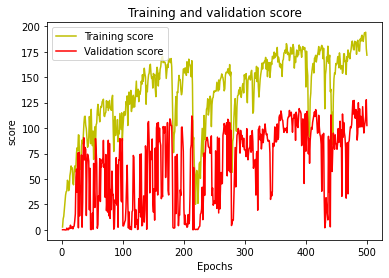

In [ ]:
score = history.history['iou_score']
val_score = history.history['val_iou_score']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, score, 'y', label='Training score')
plt.plot(epochs, val_score, 'r', label='Validation score')
plt.title('Training and validation score')
plt.xlabel('Epochs')
plt.ylabel('score')
plt.legend()
plt.show()


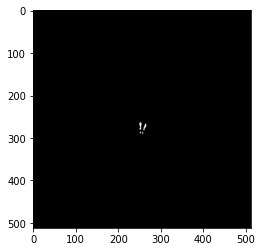

In [ ]:
test_img = cv2.imread('/content/drive/My Drive/test/train130.png', cv2.IMREAD_COLOR)       
#test_img = cv2.resize(test_img, (SIZE_Y, SIZE_X))
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = np.expand_dims(test_img, axis=0)
# 
prediction = model.predict(test_img)
# print(prediction_image)
#View and Save segmented image
prediction_image = prediction.reshape(512,512)
plt.imshow(prediction_image, cmap='gray')
# plt.imsave('/content/drive/My Drive/test/mask__130.jpg', prediction_image, cmap='gray')

In [ ]:
model_save_name = 'classifier_keras_1'
path = F"/content/drive/My Drive/test/{model_save_name}" 
model.save(path)

In [ ]:
# from keras.models import load_model
# from keras.utils.generic_utils import get_custom_objects

# get_custom_objects().update({'dice_loss': sm.losses.DiceLoss()})
# get_custom_objects().update({'iou_score': sm.metrics.IOUScore(threshold=0.5)})
# model2 = load_model(path)

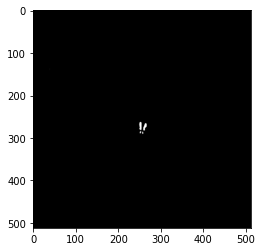

In [ ]:
# test_img = cv2.imread('/content/drive/My Drive/test/train130.png', cv2.IMREAD_COLOR)       
# #test_img = cv2.resize(test_img, (SIZE_Y, SIZE_X))
# test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
# test_img = np.expand_dims(test_img, axis=0)
# # 
# prediction = model2.predict(test_img)
# # print(prediction_image)
# #View and Save segmented image
# prediction_image = prediction.reshape(512,512)
# plt.imshow(prediction_image, cmap='gray')